# Gold Market Risk Analysis in R
## Returns, Tail Risk, Simulation, and GARCH Volatility

**Author:** Zakariya Boutayeb  
**Instrument:** COMEX gold futures (`GC=F`)  
**Analysis period:** December 2006 through December 2023


**Summary:**

This report evaluates gold-market risk using daily Yahoo Finance closing prices. It combines return construction, distribution diagnostics, parametric and empirical tail estimation, multi-day simulation, autocorrelation analysis, and a GARCH(1,1) model with Student-t innovations.

Four conclusions emerge:
- Gold returns are negatively skewed and heavy-tailed; 
- Empirical tail losses are more severe than normal-model estimates; 
- Return direction has little serial dependence while volatility clusters strongly; 
- and conditional volatility is highly persistent. 

Although the fitted GARCH model is informative, its stability and sign-bias diagnostics show that it should not be treated as a complete production model.

**Research questions:**

- How should gold returns be constructed across different horizons?
- How sensitive are VaR and ES to distributional assumptions?
- Does Student-t modeling improve the representation of tail risk?
- Does preserving the order of returns change 10-day risk estimates?
- Can a GARCH model explain the observed volatility clustering?
- What weaknesses remain after fitting GARCH?

**Project Highlights:**

- Construct daily and calendar-period returns correctly.
- Diagnose skewness, heavy tails, serial correlation, and volatility clustering.
- Estimate one-day 99% VaR and ES under several distributional approaches.
- Compare three 10-day simulations.
- Estimate a GARCH(1,1)-t model and bootstrap its one-day 95% tail risk.

**Data and sample:**

- Instrument: continuous COMEX gold futures (`GC=F`)
- Field: Yahoo Finance daily closing price
- Requested range: 2006-12-31 through 2023-12-31
- 4,275 usable daily log returns.

The instrument is a continuous gold futures series rather than physical spot gold. Futures can differ from spot because of carrying costs, contract maturities, and the method used to join successive contracts.



## Data Preparation

In [1]:
# Load packages
suppressPackageStartupMessages({
  library(quantmod)
  library(MASS)
  library(rugarch)
})

cat("Packages loaded successfully.\n")
cat("R version:", R.version.string, "\n")
cat("rugarch version:", as.character(packageVersion("rugarch")), "\n")

Packages loaded successfully.
R version: R version 4.4.3 (2025-02-28) 
rugarch version: 1.5.5 


In [2]:
# Download gold prices
gold_prices <- suppressWarnings(getSymbols("GC=F",src = "yahoo",
            from = "2006-12-31",to = "2023-12-31",auto.assign = FALSE)[, 4])

# Remove missing values
gold_prices <- na.omit(gold_prices)
names(gold_prices) <- "gold"

head(gold_prices)
tail(gold_prices)

cat("Number of price observations:", NROW(gold_prices), "\n")
cat("First available price date:", as.character(first(index(gold_prices))), "\n")
cat("Last available price date:", as.character(last(index(gold_prices))), "\n")

            gold
2007-01-02 635.2
2007-01-03 627.1
2007-01-04 623.9
2007-01-05 604.9
2007-01-08 607.5
2007-01-09 613.1

             gold
2023-12-21 2039.1
2023-12-22 2057.1
2023-12-26 2058.2
2023-12-27 2081.9
2023-12-28 2073.9
2023-12-29 2062.4

Number of price observations: 4276 
First available price date: 2007-01-02 
Last available price date: 2023-12-29 


## Return construction

In [3]:
# Calculate daily returns
# Follow the quiz instructions exactly
logret <- diff(log(gold_prices))[-1]
logret <- na.omit(logret)

# Numeric vector for simulations and statistical functions
rvec <- as.numeric(logret)

head(logret)
tail(logret)

cat("Number of daily log returns:", NROW(logret), "\n")
cat("Return sample:", as.character(first(index(logret))),
    "to", as.character(last(index(logret))), "\n")
cat("Daily log return: Date =", as.character(index(logret)[1]),
  "| Value =", sprintf("%.6f", as.numeric(logret[1])),"\n")


                   gold
2007-01-03 -0.012833951
2007-01-04 -0.005115840
2007-01-05 -0.030926943
2007-01-08  0.004288980
2007-01-09  0.009175840
2007-01-10 -0.002449581

                    gold
2023-12-21  0.0022584336
2023-12-22  0.0087887494
2023-12-26  0.0005345192
2023-12-27  0.0114491007
2023-12-28 -0.0038500458
2023-12-29 -0.0055605397

Number of daily log returns: 4275 
Return sample: 2007-01-03 to 2023-12-29 
Daily log return: Date = 2007-01-03 | Value = -0.012834 


In [4]:
# Compute calendar-period returns
monthly_log <- apply.monthly(logret, sum)
monthly_discrete <- exp(monthly_log) - 1

quarterly_log <- apply.quarterly(logret, sum)

yearly_log <- apply.yearly(logret, sum)
yearly_discrete <- exp(yearly_log) - 1

# Print dates and values
cat("Monthly discrete return: Date =",as.character(index(monthly_discrete)[1]),
    "| Value =",sprintf("%.6f", as.numeric(monthly_discrete[1])),"\n")

cat("Quarterly log return: Date =",as.character(index(quarterly_log)[NROW(quarterly_log)]),
  "| Value =",sprintf("%.6f",as.numeric(quarterly_log[NROW(quarterly_log)])),"\n")

cat("Yearly discrete return: Date =", as.character(index(yearly_discrete)[NROW(yearly_discrete)]),
  "| Value =",sprintf("%.6f", as.numeric(yearly_discrete[NROW(yearly_discrete)])),"\n")

Monthly discrete return: Date = 2007-01-31 | Value = 0.026448 
Quarterly log return: Date = 2023-12-29 | Value = 0.109712 
Yearly discrete return: Date = 2023-12-29 | Value = 0.133374 


## Normal and Empirical VaR & ES

In [5]:
alpha99 <- 0.01

# Mean and standard deviation
mu <- mean(rvec)
sigma <- sd(rvec)

# Normal-distribution VaR and ES
normal_var <- qnorm(alpha99, mu, sigma)
normal_es <- mu - sigma * dnorm(qnorm(alpha99)) / alpha99

# Simulate from the normal distribution
set.seed(123789)
normal_sim <- rnorm(100000, mu, sigma)
normal_sim_var <- as.numeric(quantile(normal_sim, alpha99))
normal_sim_es <- mean(normal_sim[normal_sim < normal_sim_var])

# Simulate from the empirical distribution
set.seed(123789)
empirical_sim <- sample(rvec, 100000, replace = TRUE)
empirical_var <- as.numeric(quantile(empirical_sim, alpha99))
empirical_es <- mean(empirical_sim[empirical_sim < empirical_var])

# Most conservative ES for a $1 billion investment
most_conservative_es <- min(normal_es, normal_sim_es, empirical_es)
portfolio_es_dollars <- round(1000000000 * most_conservative_es)

# Print every answer on one line
cat("Mean:", sprintf("%.6f", mu), "\n")
cat("Standard deviation:", sprintf("%.6f", sigma), "\n")
cat("Normal 99% VaR:", sprintf("%.6f", normal_var),"\n")
cat("Normal 99% ES:",sprintf("%.6f", normal_es),"\n")
cat("Simulated-normal 99% VaR:",sprintf("%.6f", normal_sim_var),"\n")
cat("Simulated-normal 99% ES:",sprintf("%.6f", normal_sim_es),"\n")
cat("Empirical 99% VaR:",sprintf("%.6f", empirical_var),"\n")
cat("Empirical 99% ES:",sprintf("%.6f", empirical_es),"\n")
cat("Portfolio ES in whole dollars:",format(portfolio_es_dollars,scientific = FALSE,trim = TRUE),"\n")

Mean: 0.000275 
Standard deviation: 0.011126 
Normal 99% VaR: -0.025607 
Normal 99% ES: -0.029377 
Simulated-normal 99% VaR: -0.025903 
Simulated-normal 99% ES: -0.029754 
Empirical 99% VaR: -0.031281 
Empirical 99% ES: -0.042987 
Portfolio ES in whole dollars: -42987103 


- The estimated mean daily log return is 0.000275 and the standard deviation is 0.011126.

- The exact and simulated normal results are close, validating the simulation mechanics.

- The empirical ES is materially more negative than the normal ES, demonstrating how a normal model can understate the average severity of losses in a heavy left tail.

## Distribution Diagnostics 

In [6]:
alpha99 <- 0.01
n_simulations <- 100000

# Skewness, kurtosis, and Jarque-Bera test
n <- length(rvec)
centered <- rvec - mean(rvec)
m2 <- mean(centered^2)
skewness <- mean(centered^3) / m2^(3 / 2)
kurtosis <- mean(centered^4) / m2^2
jb <- (n / 6) * (skewness^2 + (kurtosis - 3)^2 / 4)
jb_p <- pchisq(jb, df = 2, lower.tail = FALSE)

# Estimate Student-t parameters
t_fit <- suppressWarnings(fitdistr(rvec,densfun = "t"))
t_m <- unname(t_fit$estimate["m"])
t_s <- unname(t_fit$estimate["s"])
t_df <- unname(t_fit$estimate["df"])

# One-day Student-t VaR and ES
suppressWarnings(RNGkind(sample.kind = "Rounding"))
set.seed(123789)
t_1d <- t_m + t_s * rt(100000, t_df)
t_1d_var <- as.numeric(quantile(t_1d, alpha99))
t_1d_es <- mean(t_1d[t_1d < t_1d_var])

cat("Skewness:", sprintf("%.6f", skewness), "\n")
cat("Kurtosis:", sprintf("%.6f", kurtosis), "\n")
cat("Jarque-Bera statistic:", sprintf("%.6f", jb), "\n")
cat("Jarque-Bera p-value:", format(jb_p, scientific = TRUE), "\n")
cat("Student-t mean parameter (m):", sprintf("%.6f", t_m), "\n")
cat("Student-t scale parameter (s):", sprintf("%.6f", t_s), "\n")
cat("Student-t degrees of freedom:", sprintf("%.6f", t_df), "\n")
cat("Student-t one-day 99% ES:", sprintf("%.6f", t_1d_es), "\n")

Skewness: -0.244569 
Kurtosis: 8.708181 
Jarque-Bera statistic: 5846.523263 
Jarque-Bera p-value: 0e+00 
Student-t mean parameter (m): 0.000451 
Student-t scale parameter (s): 0.008747 
Student-t degrees of freedom: 7.457972 
Student-t one-day 99% ES: -0.031570 


- Negative skewness indicates asymmetry toward the loss tail. 
- Kurtosis is far above the normal benchmark of three. 
- Returns are negatively skewed and substantially more leptokurtic than a normal distribution. 
- The Jarque-Bera statistic has an effectively zero p-value and strongly rejects normality.
- The finite degrees-of-freedom estimate represents heavier tails than the normal distribution. 
- The simulated one-day 99% Student-t ES is -0.031570.

In [7]:
# Method 1: 10-day fitted Student-t simulation
suppressWarnings(RNGkind(sample.kind = "Rounding"))
set.seed(123789)
t_10d <- numeric(100000)
for (day in 1:10) {
  t_10d <- t_10d + t_m + t_s * rt(100000, t_df)
}
t_10d_var <- as.numeric(quantile(t_10d, alpha99))
t_10d_es <- mean(t_10d[t_10d < t_10d_var])

# Method 2: 10-day empirical IID simulation
suppressWarnings(RNGkind(sample.kind = "Rounding"))
set.seed(123789)
iid_10d <- numeric(100000)
for (day in 1:10) {
  iid_10d <- iid_10d + sample(rvec, 100000, replace = TRUE)
}
iid_10d_var <- as.numeric(quantile(iid_10d, alpha99))
iid_10d_es <- mean(iid_10d[iid_10d < iid_10d_var])

# Method 3: 10-day blocks of consecutive observations
suppressWarnings(RNGkind(sample.kind = "Rounding"))
set.seed(123789)
start_positions <- sample(1:(length(rvec) - 9), 100000, replace = TRUE)
block_10d <- numeric(100000)
positions <- start_positions
for (day in 1:10) {
  block_10d <- block_10d + rvec[positions]
  positions <- positions + 1
}
block_10d_var <- as.numeric(quantile(block_10d, alpha99))
block_10d_es <- mean(block_10d[block_10d < block_10d_var])

cat("Method 1 Student-t 10-day ES:", sprintf("%.6f", t_10d_es), "\n")
cat("Method 2 empirical IID 10-day ES:", sprintf("%.6f", iid_10d_es), "\n")
cat("Method 3 block 10-day ES:", sprintf("%.6f", block_10d_es), "\n")

Method 1 Student-t 10-day ES: -0.084946 
Method 2 empirical IID 10-day ES: -0.101676 
Method 3 block 10-day ES: -0.122120 


Each method creates 100,000 ten-day log returns by adding ten daily returns.

1. **Student-t IID:** draw from the fitted heavy-tailed distribution.
2. **Empirical IID:** independently resample individual historical returns.
3. **Historical blocks:** resample ten consecutive returns together.

The block estimate is most severe because it preserves short-run dependence. The difference between empirical IID and block simulation shows that the ordering of returns contains information relevant to multi-day risk.

## Time-series Diagnostics

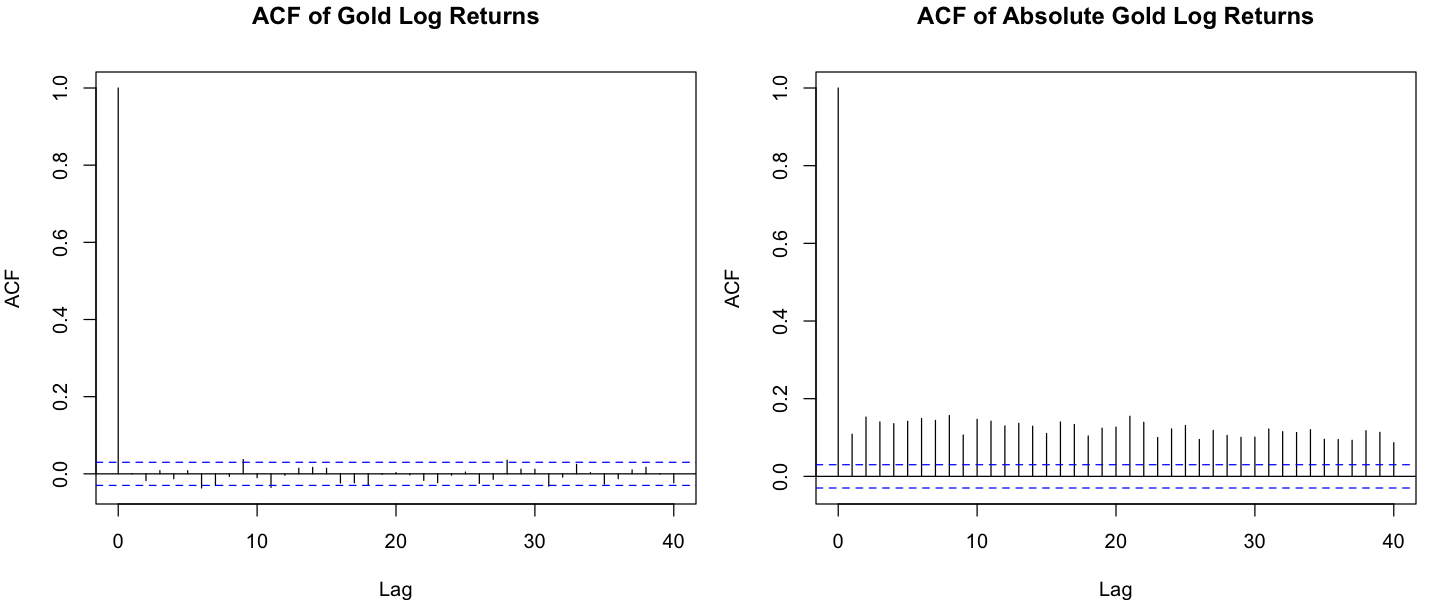

In [8]:
# ACF diagnostics
options(repr.plot.width = 12,repr.plot.height = 5)

par(mfrow = c(1, 2),mar = c(4, 4, 3, 1))

acf(rvec,lag.max = 40,main = "ACF of Gold Log Returns")
acf(abs(rvec),lag.max = 40,main = "ACF of Absolute Gold Log Returns")

par(mfrow = c(1, 1))

- The ACF of gold log returns shows no strong or persistent serial correlation, indicating that past returns provide little information about future return direction. 

- The ACF of absolute log returns remains significantly positive across many lags, providing strong evidence of volatility clustering.

- Financial returns can therefore have an unpredictable conditional mean while retaining a predictable conditional variance.

## GARCH(1,1)-t Model

In [9]:
# Specify the model GARCH(1,1)-t 
garch_spec <- ugarchspec(
  variance.model = list(model = "sGARCH", garchOrder = c(1, 1)),
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  distribution.model = "std"
)

# Estimate the model
fit.garch <- ugarchfit(garch_spec, data = logret, solver = "hybrid")
fit.garch


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: std 

Optimal Parameters
------------------------------------
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000437    0.000129   3.39571 0.000685
omega   0.000001    0.000001   0.96798 0.333053
alpha1  0.033700    0.003391   9.93744 0.000000
beta1   0.962349    0.001890 509.04843 0.000000
shape   4.403162    0.515111   8.54799 0.000000

Robust Standard Errors:
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000437    0.000143   3.06056 0.002209
omega   0.000001    0.000005   0.14184 0.887209
alpha1  0.033700    0.018522   1.81946 0.068842
beta1   0.962349    0.009344 102.99362 0.000000
shape   4.403162    2.851884   1.54395 0.122601

LogLikelihood : 13732.09 

Information Criteria
------------------------------------
     

- Weighted Ljung-Box tests on standardized residuals have high p-values, indicating little remaining linear autocorrelation.
- Weighted Ljung-Box tests on squared standardized residuals reject at several lags, although the displayed weighted ARCH LM tests do not reject. Some volatility dependence may remain.
- The Nyblom joint statistic is 642.9193 versus a reported 1% critical value of 1.88, providing strong evidence of parameter instability.
- The joint sign-bias p-value is 0.01833, suggesting asymmetric volatility effects not represented by symmetric GARCH.
- Adjusted Pearson goodness-of-fit conclusions differ across groupings.

These diagnostics motivate asymmetric and time-varying-parameter alternatives and reinforce the need for out-of-sample validation.

In [10]:
# Check convergence
fit.garch@fit$convergence

[1] 0

The optimization converged successfully.

In [11]:
# Extract GARCH parameters
garch.parameters <- coef(fit.garch)

alpha1 <- as.numeric(garch.parameters["alpha1"])
beta1 <- as.numeric(garch.parameters["beta1"])
shape <- as.numeric(garch.parameters["shape"])
persistence <- alpha1 + beta1

cat("alpha1:",sprintf("%.6f", alpha1),"\n")
cat("beta1:",sprintf("%.6f", beta1),"\n")
cat("shape:",sprintf("%.6f", shape),"\n")
cat("Volatility persistence:",sprintf("%.6f", persistence),"\n")

alpha1: 0.033700 
beta1: 0.962349 
shape: 4.403162 
Volatility persistence: 0.996048 


The persistence estimate is below but extremely close to one, so volatility shocks decay very slowly. The low Student-t shape parameter confirms that conditional returns remain heavy-tailed.


## GARCH Bootstrap VaR & ES

In [12]:
# Simulate one-day-ahead outcomes
suppressWarnings(RNGkind(sample.kind = "Rounding"))
set.seed(123789)

boot.garch <- ugarchboot(fit.garch,method = "Partial",sampling = "raw",n.ahead = 1,
                         n.bootpred = 100000,solver = "solnp")

# Extract simulated returns
garch.simulated.returns <- as.vector(boot.garch@fseries)
length(garch.simulated.returns)
summary(garch.simulated.returns)

[1] 100000

      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-0.0773399 -0.0043701  0.0004245  0.0003474  0.0055205  0.0468068 

In [13]:
# Calculate 95% GARCH VaR & ES
alpha.95 <- 0.05

VaR.garch <- as.numeric(quantile(garch.simulated.returns,probs = alpha.95))
ES.garch <- mean(garch.simulated.returns[garch.simulated.returns < VaR.garch])

cat("GARCH 95% VaR:",sprintf("%.6f", VaR.garch),"\n")
cat("GARCH 95% ES:",sprintf("%.6f", ES.garch),"\n")

GARCH 95% VaR: -0.014475 
GARCH 95% ES: -0.021511 


These are conditional estimates based on the final fitted volatility state, unlike the earlier unconditional full-sample estimates.


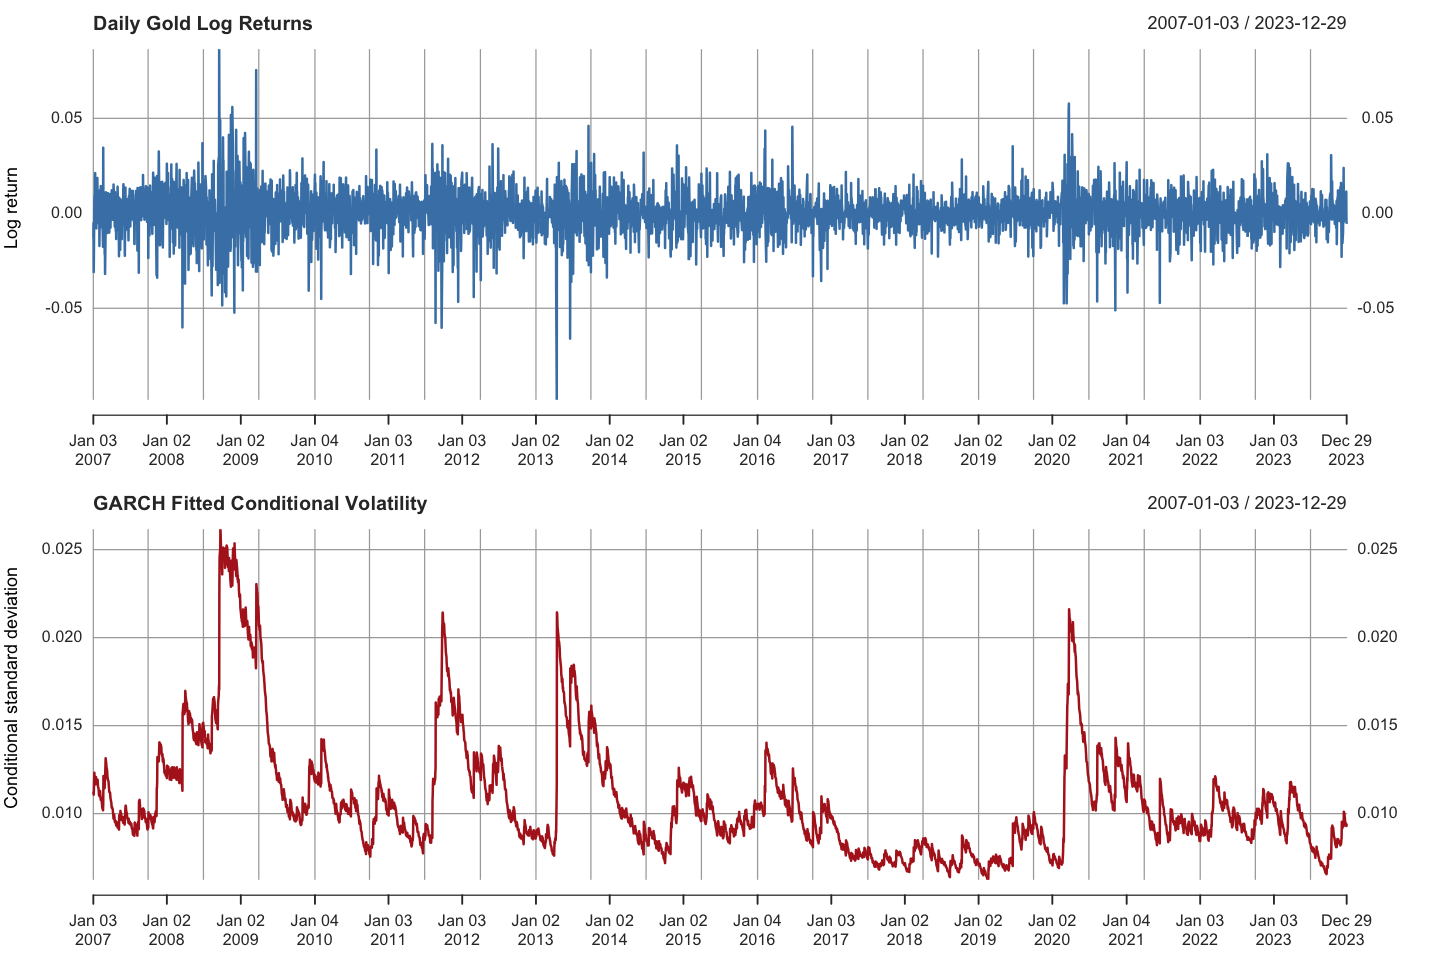

In [14]:
# Display returns and fitted volatility 
options(repr.plot.width = 12,repr.plot.height = 8)

par(mfrow = c(2, 1),mar = c(4, 4, 3, 1))

plot(logret,main = "Daily Gold Log Returns",xlab = "Date",ylab = "Log return",col = "steelblue",
     major.ticks = "years",minor.ticks = FALSE)

plot(sigma(fit.garch),main = "GARCH Fitted Conditional Volatility",xlab = "Date",
     ylab = "Conditional standard deviation",col = "firebrick",major.ticks = "years",minor.ticks = FALSE)

par(mfrow = c(1, 1))

The conditional-volatility plot shows distinct high- and low-risk regimes. A constant standard deviation cannot represent this behavior adequately.

## Conclusion

The normal model is transparent but understates the observed loss tail. Student-t simulation improves tail thickness, empirical simulation preserves actual extremes, block simulation preserves short-run dependence, and GARCH transforms volatility clustering into conditional risk estimates.

The fitted GARCH(1,1)-t model captures high persistence and heavy conditional tails, but the stability and sign-bias results prevent a claim that it fully explains the data. The strongest portfolio conclusion is therefore methodological: report VaR and ES together with their assumptions and diagnostic evidence.

